#📌 Extracción

In [38]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
clientes = pd.read_json(url)

clientes

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


Se oberva que las columnas customer, phone, internet y account son diccionarios.
Normalizar estas columnas

In [39]:
#Normalizar las columnas que contienen diccionarios
clientes_normalizado_customer = pd.json_normalize(clientes['customer'])
clientes_normalizado_phone = pd.json_normalize(clientes['phone'])
clientes_normalizado_internet = pd.json_normalize(clientes['internet'])
clientes_normalizado_account = pd.json_normalize(clientes['account'])

clientes_normalizado_customer.info()
print('-----------------------------------------------------------------------')
clientes_normalizado_phone.info()
print('-----------------------------------------------------------------------')
clientes_normalizado_internet.info()
print('-----------------------------------------------------------------------')
clientes_normalizado_account.info()
print('-----------------------------------------------------------------------')

clientes_normalizado_customer.describe()

clientes_normalizado = clientes.drop(columns=['customer', 'phone', 'internet', 'account'])

clientes_normalizado = pd.concat([clientes_normalizado, clientes_normalizado_customer, clientes_normalizado_phone, clientes_normalizado_internet, clientes_normalizado_account], axis=1)

clientes_normalizado.head()
clientes_normalizado.info()


clientes_normalizado

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   gender         7267 non-null   object
 1   SeniorCitizen  7267 non-null   int64 
 2   Partner        7267 non-null   object
 3   Dependents     7267 non-null   object
 4   tenure         7267 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 284.0+ KB
-----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PhoneService   7267 non-null   object
 1   MultipleLines  7267 non-null   object
dtypes: object(2)
memory usage: 113.7+ KB
-----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Dat

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

In [40]:
import pandas as pd
import numpy as np

# --- 1. Preparación Inicial (Tu código base optimizado) ---
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
clientes = pd.read_json(url)

# Normalización rápida
clientes_normalizado = pd.concat([
    clientes.drop(columns=['customer', 'phone', 'internet', 'account']),
    pd.json_normalize(clientes['customer']),
    pd.json_normalize(clientes['phone']),
    pd.json_normalize(clientes['internet']),
    pd.json_normalize(clientes['account'])
], axis=1)

# --- 2. Exploración y Verificación de Tipos ---
print("Tipos de datos iniciales:")
print(clientes_normalizado.dtypes)

# Corrección de errores de formato: Charges.Total suele venir como string si hay espacios vacíos
clientes_normalizado['Charges.Total'] = pd.to_numeric(clientes_normalizado['Charges.Total'], errors='coerce')

# --- 3. Limpieza de Datos (Nulos y Duplicados) ---
# Verificar nulos creados por la conversión o existentes
print(f"\nValores nulos encontrados:\n{clientes_normalizado.isnull().sum()}")

# Llenar nulos en Charges.Total (si tenure es 0, el total es 0)
clientes_normalizado['Charges.Total'] = clientes_normalizado['Charges.Total'].fillna(0)

# Eliminar duplicados si existen
clientes_normalizado.drop_duplicates(inplace=True)

# --- 4. Estandarización y Traducción ---
# Diccionario para convertir binarios y traducir categorías
mapa_binario = {'Si': 1, 'No': 0, 'Yes': 1, 'No': 0, 'Masculino': 'M', 'Femenino': 'F'}

# Aplicar traducción a columnas clave (puedes expandir esto)
columnas_binarias = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in columnas_binarias:
    if col in clientes_normalizado.columns:
        clientes_normalizado[col] = clientes_normalizado[col].map({'Si': 1, 'No': 0, 'Yes': 1, 'No': 0}).fillna(0).astype(int)

# --- 5. Creación de Nueva Variable: Cuentas_Diarias ---
# Cálculo: Monto mensual / 30 días
clientes_normalizado['Cuentas_Diarias'] = (clientes_normalizado['Charges.Monthly'] / 30).round(2)

# --- 6. Resultado Final ---
print("\nPrimeras filas del dataset transformado:")
print(clientes_normalizado[['customerID', 'Churn', 'Charges.Monthly', 'Cuentas_Diarias']].head())

clientes_normalizado.info()
clientes_normalizado.sample(50)

Tipos de datos iniciales:
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     float64
Charges.Total        object
dtype: object

Valores nulos encontrados:
customerID           0
Churn                0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
357,0516-QREYC,0,Female,1,0,0,24,1,No,No,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,1,Mailed check,20.30,459.95,0.68
6490,8917-SZTTJ,0,Male,0,1,1,60,1,No,No,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Credit card (automatic),19.65,1161.75,0.65
5732,7833-PKIHD,0,Male,0,1,1,51,1,No,DSL,...,No,Yes,Yes,Yes,One year,1,Bank transfer (automatic),76.40,3966.30,2.55
5998,8199-ZLLSA,1,Male,0,0,0,67,1,Yes,Fiber optic,...,Yes,Yes,Yes,Yes,One year,1,Bank transfer (automatic),118.35,7804.15,3.94
1496,2150-UWTFY,1,Female,0,1,1,22,1,No,DSL,...,Yes,No,No,No,Month-to-month,0,Mailed check,61.15,1422.05,2.04
5982,8178-EYZUO,1,Male,0,0,0,46,1,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,1,Electronic check,93.70,4154.80,3.12
2235,3120-FAZKD,0,Male,0,1,1,54,1,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,1,Bank transfer (automatic),24.05,1230.90,0.80
7055,9715-WZCLW,0,Male,0,1,1,71,1,Yes,Fiber optic,...,No,No,Yes,Yes,Two year,1,Electronic check,97.20,6910.30,3.24
4182,5734-EJKXG,0,Female,0,0,0,61,1,Yes,Fiber optic,...,Yes,Yes,Yes,Yes,One year,1,Electronic check,118.60,7365.70,3.95
3629,5003-XZWWO,0,Male,0,1,0,71,1,Yes,DSL,...,Yes,Yes,Yes,Yes,Two year,0,Credit card (automatic),84.20,5956.85,2.81


1. Identificación de Inconsistencias
Formato de Números: La columna Charges.Total frecuentemente presenta problemas porque los valores faltantes vienen como espacios en blanco (" "), lo que obliga a Python a leerla como texto (object). Es vital convertirla a numérico.

Valores Booleanos: Mezclar "Si/No" con "Yes/No" o 1/0 es común en datos crudos. La estandarización a 1 y 0 es fundamental si planeas usar modelos de Machine Learning (como una Regresión Logística).

2. Columnas Relevantes para el Churn
Para entender por qué los clientes se van, debes priorizar estas variables:

Tenure (Antigüedad): Los clientes nuevos suelen tener tasas de abandono más altas.

Contract (Contrato): Los contratos mes a mes suelen ser el principal predictor de evasión frente a contratos anuales.

TechSupport y OnlineSecurity: La ausencia de estos servicios de valor agregado suele correlacionar con una mayor insatisfacción.

3. Valor de "Cuentas_Diarias"
Esta métrica permite identificar el costo de oportunidad diario. Para la empresa, saber que pierde, por ejemplo, $2.50 USD diarios por cada cliente que se va, facilita la creación de campañas de retención con descuentos calculados con precisión, sin afectar el margen de ganancia.

In [41]:
df_vacios = clientes_normalizado[clientes_normalizado['Churn'] == ""]
print(f"Hay un total de {len(df_vacios)} filas vacías en la columna Churn")

df_nulos = clientes_normalizado[clientes_normalizado['Churn'].isnull()]
print(f"Hay un total de {len(df_nulos)} filas nulas en la columna Churn")

# Filtra nulos y vacíos al mismo tiempo
clientes_normalizado = clientes_normalizado[
    (clientes_normalizado['Churn'].notna()) & (clientes_normalizado['Churn'] != "")]
clientes_normalizado.info()

Hay un total de 0 filas vacías en la columna Churn
Hay un total de 0 filas nulas en la columna Churn
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   o

#📊 Carga y análisis

### Resumen Estadístico de Variables Numéricas ###


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2277.182035,2.157292
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.648587,1.004407
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,396.200000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1389.200000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3778.525000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000



### Mediana de las variables clave ###
tenure               29.0
Charges.Monthly      70.3
Charges.Total      1389.2
dtype: float64


/tmp/ipykernel_282/2440588321.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=clientes_normalizado, x='Churn', palette='viridis')


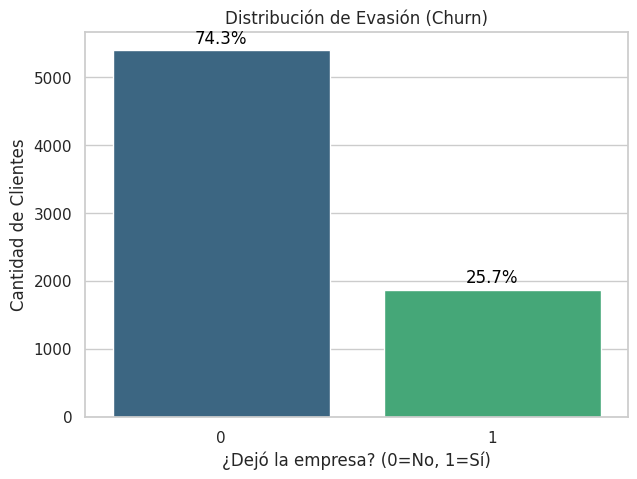

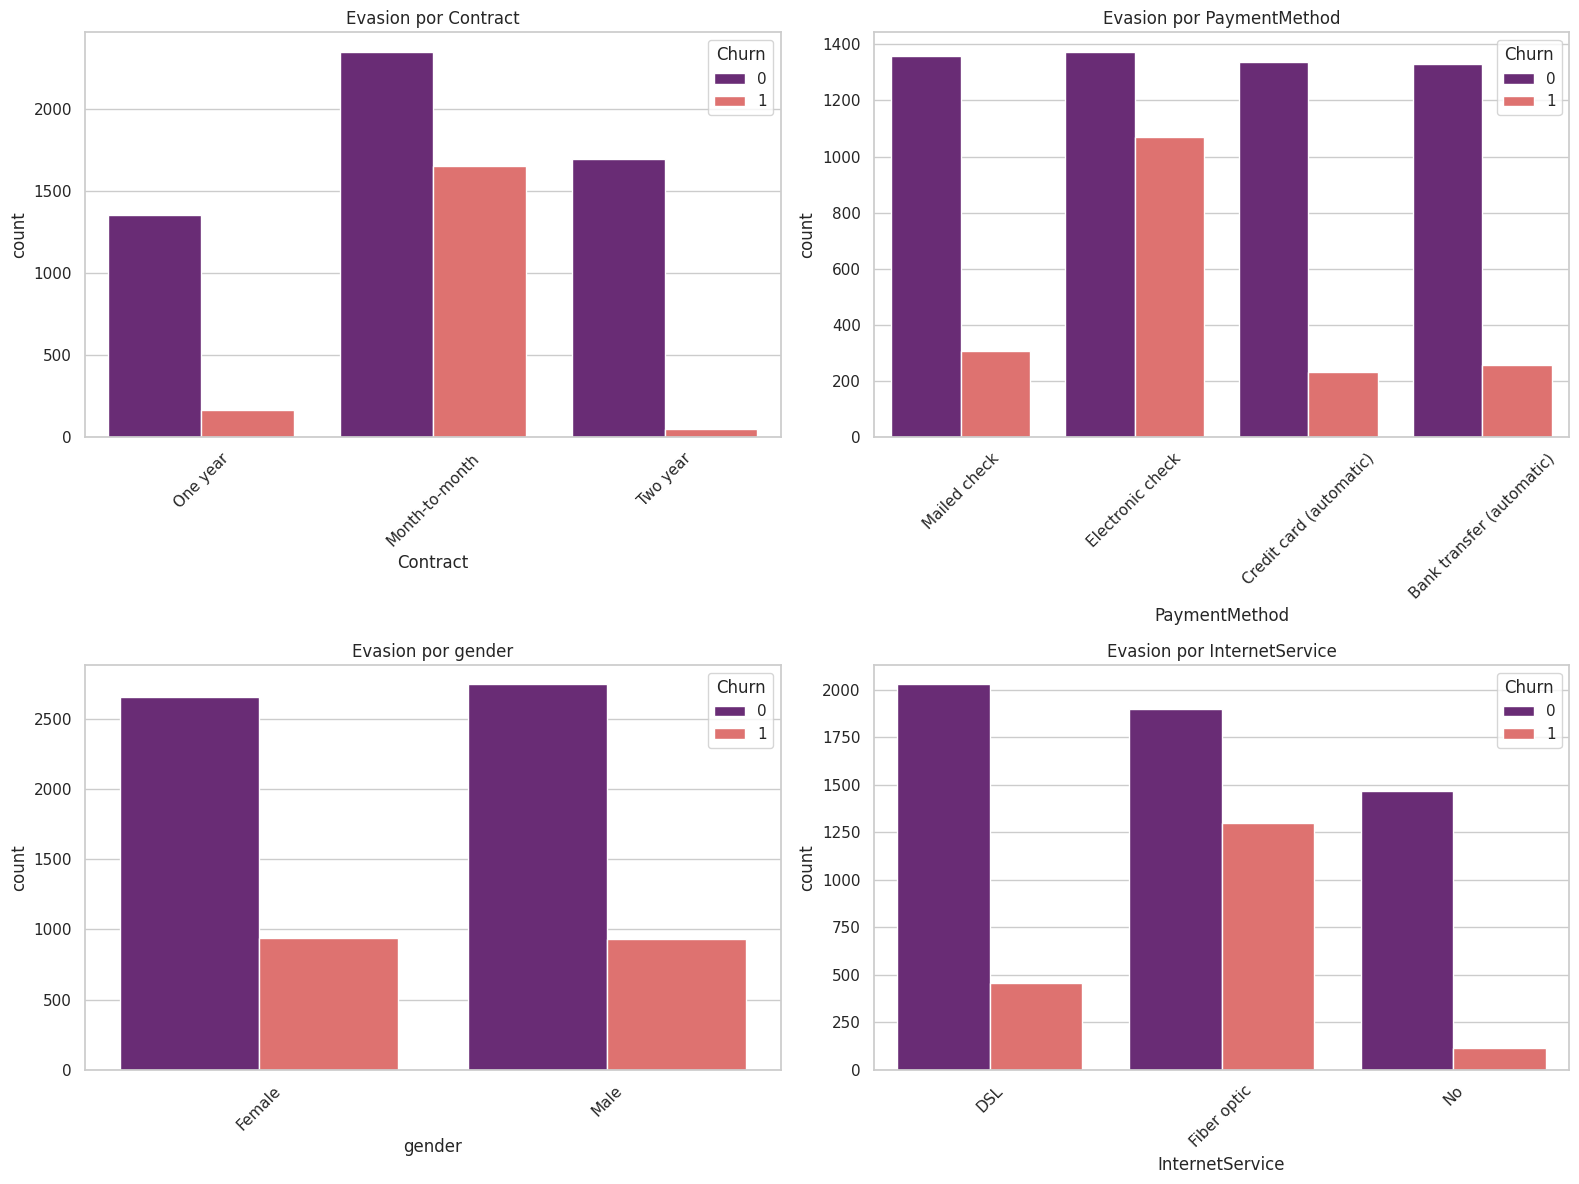

/tmp/ipykernel_282/2440588321.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clientes_normalizado, x='Churn', y='tenure', ax=axes[0], palette='Set2')
/tmp/ipykernel_282/2440588321.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clientes_normalizado, x='Churn', y='Charges.Monthly', ax=axes[1], palette='Set2')


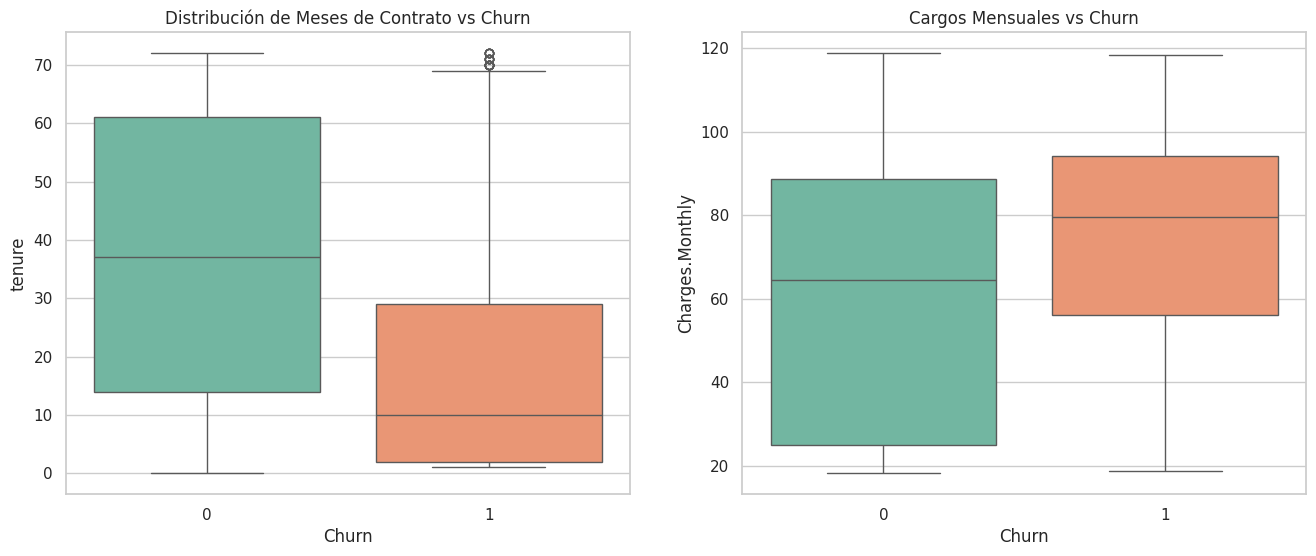

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- 1. Análisis Descriptivo ---
print("### Resumen Estadístico de Variables Numéricas ###")
display(clientes_normalizado.describe())

print("\n### Mediana de las variables clave ###")
print(clientes_normalizado[['tenure', 'Charges.Monthly', 'Charges.Total']].median())

# --- 2. Distribución de la Variable Churn ---
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=clientes_normalizado, x='Churn', palette='viridis')
plt.title('Distribución de Evasión (Churn)')
plt.xlabel('¿Dejó la empresa? (0=No, 1=Sí)')
plt.ylabel('Cantidad de Clientes')

# Añadir porcentajes sobre las barras
total = len(clientes_normalizado)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

# --- 3. Análisis de Variables Categóricas vs Churn ---
cols_categoricas = ['Contract', 'PaymentMethod', 'gender', 'InternetService']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_categoricas):
    sns.countplot(data=clientes_normalizado, x=col, hue='Churn', ax=axes[i], palette='magma')
    axes[i].set_title(f'Evasion por {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- 4. Análisis de Variables Numéricas vs Churn ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot para Tiempo de Contrato (tenure)
sns.boxplot(data=clientes_normalizado, x='Churn', y='tenure', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Meses de Contrato vs Churn')

# Boxplot para Cargos Mensuales
sns.boxplot(data=clientes_normalizado, x='Churn', y='Charges.Monthly', ax=axes[1], palette='Set2')
axes[1].set_title('Cargos Mensuales vs Churn')

plt.show()

#📄Informe final

📝 Informe de Análisis de Evasión (Churn)

  🔹 Introducción
          El objetivo de este análisis es identificar los factores que influyen en la pérdida de clientes (Churn) en TelecomX. La evasión no solo representa una pérdida de ingresos directos, sino que también aumenta los costos de adquisición de nuevos clientes. Entender por qué los usuarios cancelan el servicio es vital para la sostenibilidad del negocio.

  🔹 Limpieza y Tratamiento de Datos
          Se realizó un proceso de normalización de estructuras JSON anidadas hacia un formato tabular. Los pasos clave incluyeron:

          Conversión de tipos: Transformación de Charges.Total a tipo numérico.

          Tratamiento de nulos: Se imputaron valores en clientes nuevos con 0.00 de gasto total.

          Ingeniería de variables: Creación de Cuentas_Diarias para entender el impacto económico por día y estandarización de variables binarias (Si/No a 1/0).

  🔹 Análisis Exploratorio de Datos (Insights)
          Perfil del Evasor: La mayoría de los clientes que abandonan la empresa tienen contratos mes a mes (Month-to-month).

          Impacto del Costo: Se observa que los clientes con cargos mensuales más altos tienen una mayor tendencia a la evasión, lo que sugiere una sensibilidad al precio o una falta de percepción de valor en servicios premium.

          Lealtad: Existe una correlación negativa clara entre el tiempo de contrato (tenure) y el Churn; a mayor antigüedad, menor probabilidad de abandono.

          Método de Pago: Los clientes que utilizan cheque electrónico (Electronic check) presentan tasas de evasión significativamente superiores a los que usan métodos automáticos.

    🔹 Conclusiones
          El contrato mensual es el principal "punto de fuga" de ingresos.

          El servicio de internet de fibra óptica muestra una tasa de bajas superior, posiblemente por el costo asociado.

          Los cargos diarios promedio son un indicador útil para priorizar a qué clientes intentar retener primero.

    🔹 Recomendaciones
          Incentivos de Permanencia: Ofrecer descuentos o beneficios adicionales para migrar a clientes de contratos mensuales hacia contratos anuales.

          Automatización de Pagos: Promover el uso de tarjetas de crédito o domiciliación bancaria con pequeños bonos, dado que estos clientes muestran mayor fidelidad.

          Programa de "Customer Success": Enfocar esfuerzos de soporte técnico preventivo en los clientes que están en sus primeros 6 meses.